### Packages & Directory

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

# Set the style of the plot
sns.set(style="whitegrid", palette='pastel')

In [2]:
# Specify the paths to the dataframe.
condition = 'IM' # IM or SF
directory = f"C:/Users/monik/Documents/Paris/Internship/Data-Collection/Extracted-Data/Glides-Notes/{condition}/"

In [3]:
# Check the path
f"{directory}JOINED_data_{condition}.csv"

'C:/Users/monik/Documents/Paris/Internship/Data-Collection/Extracted-Data/Glides-Notes/IM/JOINED_data_IM.csv'

### Read in the data.

In [4]:
# The joined dataframe of extracted features
df = pd.read_csv(f"{directory}JOINED_data_{condition}.csv",  sep=',', index_col=0, dtype={'PARTICIPANT_ID':str, 
                                                                                          'SONG_ID':str})
df.head()
# When joining the datasets of all participants, the program will return the DtypeWarning for 'PARTICIPANT_ID' column because
# the IDs consist of 6-letter and 6-number codes (different types). To resolve the warning, specify dtype of this column.

,TIME_FRAME,FUNDAMENTAL_FREQUENCY,MIDI_NOTE,NG_type,NG_ID,NG,PARTICIPANT_ID,SONG_ID
0,0.000000,NaN,NaN,NaN,NaN,NaN,292711,1
1,0.023230,NaN,NaN,NaN,NaN,NaN,292711,1
2,0.046460,NaN,NaN,NaN,NaN,NaN,292711,1
3,0.069689,NaN,NaN,NaN,NaN,NaN,292711,1
4,0.092919,NaN,NaN,NaN,NaN,NaN,292711,1


In [5]:
# The vocal range datafame
VR = pd.read_csv('C:/Users/monik/Documents/Paris/Internship/Data-Collection/Extracted-Data/VR/VR_modified_all.csv',
                 sep=',', index_col=0, dtype={'PARTICIPANT_ID':str})
VR

,PARTICIPANT_ID,MEAN_f0,MEDIAN_f0,MAX_f0,MIN_f0,RANGE_f0,MEAN_MIDI,MEDIAN_MIDI,MAX_MIDI,MIN_MIDI,RANGE_MIDI
0,292711,300.47,288.49,515.60,155.00,360.60,62.40,61.69,71.74,50.94,20.81
1,783520,301.23,294.99,529.48,148.56,380.92,62.44,62.08,72.20,50.20,22.00
2,957921,123.11,117.80,187.26,78.96,108.30,46.95,46.19,54.21,39.26,14.95
3,djtosh,239.59,233.16,409.67,81.44,328.23,58.48,58.01,67.76,39.80,27.97
4,fosmvm,221.28,107.09,292.86,72.01,220.85,57.10,44.54,61.95,37.67,24.29
5,fubqui,303.73,191.17,955.65,70.26,885.39,62.58,54.57,82.43,37.24,45.19
6,fxdrni,182.02,166.63,298.90,112.60,186.30,53.72,52.19,62.31,45.40,16.90
7,glbbwi,152.54,140.55,290.87,75.82,215.05,50.66,49.24,61.83,38.56,23.28
8,kdkycn,254.51,259.45,352.86,136.61,216.25,59.52,59.86,65.18,48.75,16.43
9,lfraeu,328.68,150.74,659.75,74.12,585.63,63.95,50.45,76.01,38.17,37.85


In [6]:
# Check that participants in VR and extracted dataset are the same
assert df['PARTICIPANT_ID'].unique().all() == VR['PARTICIPANT_ID'].unique().all()

## Detect dirty data.

In [7]:
# Remove the first few time frames which is in total about 50 ms.

# Select rows
TF = df.loc[df['TIME_FRAME'] <= 0.06]

# Get the indices of the rows
TF_idx = TF.index.tolist()

# Drop the rows by index
df = df.drop(index=TF_idx)

In [8]:
# Remove rows with f0 above 1350 for all (usually breathing artifacts)

FZ = df.loc[df['FUNDAMENTAL_FREQUENCY'] >= 1350]
FZ_idx = FZ.index.tolist()
df = df.drop(index=FZ_idx)

In [9]:
# Remove rows with f0 below 50 Hz for all (usually movement artifacts)

FM = df.loc[df['FUNDAMENTAL_FREQUENCY'] <= 50]
FM_idx = FM.index.tolist()
df = df.drop(index=FM_idx)

In [10]:
# Check that all the wanted is removed. If all good, get False.
print((df['TIME_FRAME'] <= 0.05).any())
print((df['FUNDAMENTAL_FREQUENCY'] >= 1350).any())
print((df['FUNDAMENTAL_FREQUENCY'] <= 50).any())

False
False
False


In [21]:
# Remove specific data

# 292711 ---------------------------------------------------------------
p = '292711'
d = df[df['PARTICIPANT_ID'] == p]

r1_292711 = ['2', '3', '4', '5', '15', '23', '29']
for i in r1_292711:
    r1 = d[(d['SONG_ID'] == i) & (d['FUNDAMENTAL_FREQUENCY'] < 100)]
    r1_idx = r1.index.tolist()
    df = df.drop(index=r1_idx)

r2_292711 = ['26']
for i in r2_292711:
    r2 = d[(d['SONG_ID'] == i) & (d['FUNDAMENTAL_FREQUENCY'] < 160)]
    r2_idx = r2.index.tolist()
    df = df.drop(index=r2_idx)

r3_292711 = ['18', '22']
for i in r3_292711:
    r3 = d[(d['SONG_ID'] == i) & (d['FUNDAMENTAL_FREQUENCY'] < 200)]
    r3_idx = r3.index.tolist()
    df = df.drop(index=r3_idx)

r4 = d[(d['SONG_ID'] == '14') & (d['FUNDAMENTAL_FREQUENCY'] < 250)]
r4_idx = r4.index.tolist()
df = df.drop(index=r4_idx)

r5 = d[(d['SONG_ID'] == '14') & (d['FUNDAMENTAL_FREQUENCY'] > 505)]
r5_idx = r5.index.tolist()
df = df.drop(index=r5_idx)

r6 = d[(d['SONG_ID'] == '17') & (d['FUNDAMENTAL_FREQUENCY'] > 600)]
r6_idx = r6.index.tolist()
df = df.drop(index=r6_idx)

r7 = d[(d['SONG_ID'] == '15') & (d['FUNDAMENTAL_FREQUENCY'] > 400)]
r7_idx = r7.index.tolist()
df = df.drop(index=r7_idx)

r8 = d[(d['SONG_ID'] == '15') & (d['TIME_FRAME'] < 4.2)]
r8_idx = r8.index.tolist()
df = df.drop(index=r8_idx)

r9 = d[(d['SONG_ID'] == '21') & (d['FUNDAMENTAL_FREQUENCY'] > 550)]
r9_idx = r9.index.tolist()
df = df.drop(index=r9_idx)

    # Song 8: no pitch also with Tony algorithm !
song8 = df[(df['SONG_ID'] == '8') & (df['PARTICIPANT_ID'] == '292711')]
s8_idx = song8.index.tolist()
df = df.drop(index=s8_idx)

# 783520 ---------------------------------------------------------------
p = '783520'
d = df[df['PARTICIPANT_ID'] == p]

r1_783520 = ['1', '4', '5', '27']
for i in r1_783520:
    r1 = d[(d['SONG_ID'] == i) & (d['FUNDAMENTAL_FREQUENCY'] < 100)]
    r1_idx = r1.index.tolist()
    df = df.drop(index=r1_idx)

r2_783520 = ['21', '28']
for i in r2_783520:
    r2 = d[(d['SONG_ID'] == i) & (d['FUNDAMENTAL_FREQUENCY'] < 200)]
    r2_idx = r2.index.tolist()
    df = df.drop(index=r2_idx)

r3 = d[(d['SONG_ID'] == '15') & (d['FUNDAMENTAL_FREQUENCY'] > 1200)]
r3_idx = r3.index.tolist()
df = df.drop(index=r3_idx)

r4 = d[(d['SONG_ID'] == '4') & (d['FUNDAMENTAL_FREQUENCY'] < 144)]
r4_idx = r4.index.tolist()
df = df.drop(index=r4_idx)

r5 = d[(d['SONG_ID'] == '14') & (d['FUNDAMENTAL_FREQUENCY'] < 150)]
r5_idx = r5.index.tolist()
df = df.drop(index=r5_idx)

# 957921 ---------------------------------------------------------------
p = '957921'
d = df[df['PARTICIPANT_ID'] == p]

r1_957921 = ['5']
for i in r1_957921:
    r1 = d[(d['SONG_ID'] == i) & (d['TIME_FRAME'] < 3.8)]
    r1_idx = r1.index.tolist()
    df = df.drop(index=r1_idx)

r2 = d[d['FUNDAMENTAL_FREQUENCY'] < 75]
r2_idx = r2.index.tolist()
df = df.drop(index=r2_idx)

# djtosh ---------------------------------------------------------------
p = 'djtosh'
d = df[df['PARTICIPANT_ID'] == p]

r1_djtosh = ['1','2','3','6','8', '9', '14']
for i in r1_djtosh:
    r1 = d[(d['SONG_ID'] == i) & (d['FUNDAMENTAL_FREQUENCY'] < 100)]
    r1_idx = r1.index.tolist()
    df = df.drop(index=r1_idx)

r2_djtosh = ['12', '14']
for i in r2_djtosh:
    r2 = d[(d['SONG_ID'] == i) & (d['FUNDAMENTAL_FREQUENCY'] > 500)]
    r2_idx = r2.index.tolist()
    df = df.drop(index=r2_idx)

r3_djtosh = ['4']
for i in r3_djtosh:
    r3 = d[(d['SONG_ID'] == i) & (d['FUNDAMENTAL_FREQUENCY'] < 200)]
    r3_idx = r3.index.tolist()
    df = df.drop(index=r3_idx)

# fxdrni ---------------------------------------------------------------
p = 'fxdrni'
d = df[df['PARTICIPANT_ID'] == p]

r1_fxdrni = ['30']
for i in r1_fxdrni:
    r1 = d[(d['SONG_ID'] == i) & (d['FUNDAMENTAL_FREQUENCY'] < 50)]
    r1_idx = r1.index.tolist()
    df = df.drop(index=r1_idx)

r2_fxdrni = ['14', '28', '30']
for i in r2_fxdrni:
    r2 = d[(d['SONG_ID'] == i) & (d['FUNDAMENTAL_FREQUENCY'] > 400)]
    r2_idx = r2.index.tolist()
    df = df.drop(index=r2_idx)

# kdkycn ---------------------------------------------------------------
p = 'kdkycn'
d = df[df['PARTICIPANT_ID'] == p]

r1_kdkycn = ['15']
for i in r1_kdkycn:
    r1 = d[(d['SONG_ID'] == i) & (d['FUNDAMENTAL_FREQUENCY'] > 1000)]
    r1_idx = r1.index.tolist()
    df = df.drop(index=r1_idx)

# lfraeu ---------------------------------------------------------------
p = 'lfraeu'
d = df[df['PARTICIPANT_ID'] == p]

r1_lfraeu = ['18']
for i in r1_lfraeu:
    r1 = d[(d['SONG_ID'] == i) & (d['FUNDAMENTAL_FREQUENCY'] > 1200)]
    r1_idx = r1.index.tolist()
    df = df.drop(index=r1_idx)

r2_lfraeu = ['18']
for i in r2_lfraeu:
    r2 = d[(d['SONG_ID'] == i) & (d['FUNDAMENTAL_FREQUENCY'] < 60)]
    r2_idx = r2.index.tolist()
    df = df.drop(index=r2_idx)
    
# sdwmkv ---------------------------------------------------------------
p = 'sdwmkv'
d = df[df['PARTICIPANT_ID'] == p]

r1_sdwmkv = ['15']
for i in r1_sdwmkv:
    r1 = d[(d['SONG_ID'] == i) & (d['FUNDAMENTAL_FREQUENCY'] > 1000)]
    r1_idx = r1.index.tolist()
    df = df.drop(index=r1_idx)

# vroghc ---------------------------------------------------------------
p = 'vroghc'
d = df[df['PARTICIPANT_ID'] == p]

r1_vroghc = ['11']
for i in r1_vroghc:
    r1 = d[(d['SONG_ID'] == i) & (d['FUNDAMENTAL_FREQUENCY'] > 800)]
    r1_idx = r1.index.tolist()
    df = df.drop(index=r1_idx)

# wxbeka ---------------------------------------------------------------
p = 'wxbeka'
d = df[df['PARTICIPANT_ID'] == p]

r1_wxbeka = ['17', '22', '23', '27']
for i in r1_wxbeka:
    r1 = d[(d['SONG_ID'] == i) & (d['FUNDAMENTAL_FREQUENCY'] > 800)]
    r1_idx = r1.index.tolist()
    df = df.drop(index=r1_idx)

# ytzemq ---------------------------------------------------------------
p = 'ytzemq'
d = df[df['PARTICIPANT_ID'] == p]

r1_ytzemq = ['30']
for i in r1_ytzemq:
    r1 = d[(d['SONG_ID'] == i) & (d['FUNDAMENTAL_FREQUENCY'] > 600)]
    r1_idx = r1.index.tolist()
    df = df.drop(index=r1_idx)

#### Plot

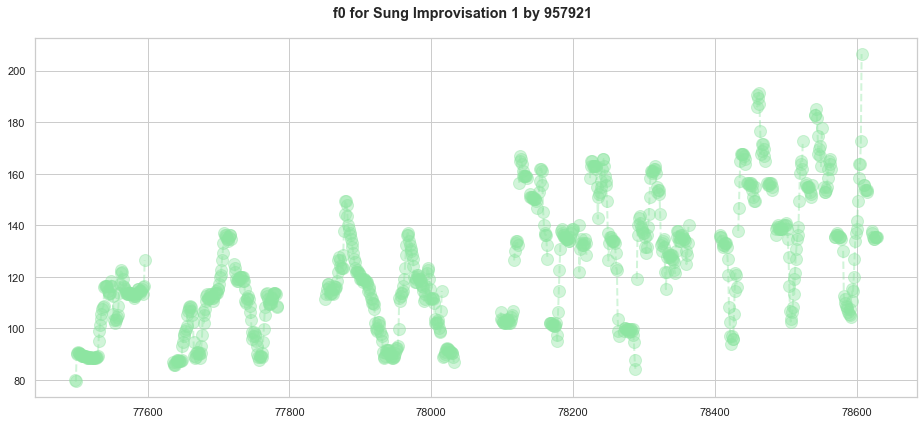

In [22]:
# Plot f0 of song S by participant P
S = '1'
P = '957921'
song_f0 = df[(df['SONG_ID'] == S) & (df['PARTICIPANT_ID'] == P)]['FUNDAMENTAL_FREQUENCY']

fig = plt.figure(figsize=(13, 6))
line1, = plt.plot(song_f0, color = 'g', alpha = 0.4, marker='o', linestyle='dashed', linewidth=2, markersize=12)
fig.suptitle(f'f0 for Sung Improvisation {S} by {P}', fontweight ="bold", size='large')
fig.tight_layout()

# Save
#fig.savefig(f"{S}_{P}_{condition}.png", dpi=300)

In [ ]:
# Plot NOTES of song S by participant P
S = '21'
P = '783520'

song_MIDI = df[(df['SONG_ID'] == S) & (df['PARTICIPANT_ID'] == P)]['MIDI_NOTE']
song_NG = df[(df['SONG_ID'] == S) & (df['PARTICIPANT_ID'] == P)]['NG']

fig = plt.figure(figsize=(13, 6))
line2, = plt.plot(song_MIDI, color = 'r', alpha = 0.4, marker='o', linestyle='dashed', linewidth=2, markersize=12)
line3, = plt.plot(song_NG, color = 'b', alpha = 0.05, marker='o', linestyle='dashed', linewidth=2, markersize=12)

plt.legend([line2, line3], ['MIDI', 'NG'])
fig.suptitle(f'MIDI and NG for Sung Improvisation {S} by {P}', fontweight ="bold", size='large')
fig.tight_layout()

# Save
#fig.savefig(f"Sung Improvisation {S} by {P}.png", dpi=300)

### Data Types

#### Do the variables have the correct data type?

In [ ]:
# Print the info
print(df.info())

In [ ]:
# Add song type column
if condition == 'SF':
    song_forms = []
    for songID in df['SONG_ID']:
        #print(songID)
        A = songID.split("_")
        #print(A)
        song_forms.append(A[0])


    df['SONG_TYPE'] = song_forms

    # Check the change
    print(df['SONG_TYPE'].unique())

### Data Range

In [ ]:
# Print summary statistics
print(df.describe())

In [ ]:
# Check whether the extracted max & min for f0, MIDI, and NG are higher than values extracted from VR data.
# assert df['FUNDAMENTAL_FREQUENCY'].max() <= VR['MAX_f0'].any()
# assert df['MIDI_NOTE'].max() <= VR['MAX_MIDI'].any()
# assert df['NG'].max() <= VR['MAX_MIDI'].any()

# assert df['FUNDAMENTAL_FREQUENCY'].max() <= VR['MIN_f0'].any()
# assert df['MIDI_NOTE'].max() <= VR['MIN_MIDI'].any()
# assert df['NG'].max() <= VR['MIN_MIDI'].any()

###### f0, MIDI, NG over Time per Song & Participant (time)

In [ ]:
# f0 over time per participants' sung improvisations
_ = sns.relplot(data=df, x=df['TIME_FRAME'], y=df['FUNDAMENTAL_FREQUENCY'],
                col=df['PARTICIPANT_ID'], col_wrap=4, hue=df['SONG_ID'], kind='line')
# Set title
_.fig.suptitle('f0 over Time for All Sung Improvisations per Participant', y=1, va='baseline', fontsize=18)

# Add MAX & MIN f0 from VR data as horizontal lines on each subplot (per participant)
for i, ax in enumerate(_.axes.flat):
    ax.axhline(y=VR.loc[i,'MAX_f0'], linestyle='--', linewidth=2, color='black')
    ax.axhline(y=VR.loc[i,'MIN_f0'], linestyle='--', linewidth=2, color='black')
    ax.set_xlabel('Time Frame', visible=True)

# Save
#plt.savefig(f"f0-over-time_{condition}.png", dpi=300)

In [ ]:
# MIDI over time per participants' sung improvisations
_ = sns.relplot(data=df, x=df['TIME_FRAME'], y=df['MIDI_NOTE'],
                col=df['PARTICIPANT_ID'], col_wrap=4, hue=df['SONG_ID'], kind='line')

# Set title
_.fig.suptitle('MIDI over Time for Sung Improvisations per Participant', y=1, va='baseline', fontsize=18)

# Add MAX & MIN MIDI note from VR data as horizontal lines on each subplot (per participant)
for i, ax in enumerate(_.axes.flat):
    ax.axhline(y=VR.loc[i,'MAX_MIDI'], linestyle='--', linewidth=2, color='black')
    ax.axhline(y=VR.loc[i,'MIN_MIDI'], linestyle='--', linewidth=2, color='black')
    ax.set_xlabel('Time Frame', visible=True)

# Save
#plt.savefig(f"MIDI-over-time_{condition}.png", dpi=300)

In [ ]:
# NG over time per participants' sung improvisations
_ = sns.relplot(data=df, x=df['TIME_FRAME'], y=df['NG'],
                col=df['PARTICIPANT_ID'], col_wrap=4, hue=df['SONG_ID'], kind='line')
# Set title
_.fig.suptitle('NG over Time for All Sung Improvisations per Participant', y=1, va='baseline', fontsize=18)

# Add MAX & MIN MIDI note from VR data as horizontal lines on each subplot (per participant)
for i, ax in enumerate(_.axes.flat):
    ax.axhline(y=VR.loc[i,'MAX_MIDI'], linestyle='--', linewidth=2, color='black')
    ax.axhline(y=VR.loc[i,'MIN_MIDI'], linestyle='--', linewidth=2, color='black')
    ax.set_xlabel('Time Frame', visible=True)

# Save
#plt.savefig(f"NG-over-time_{condition}.png", dpi=300)

###### f0, MIDI, NG over Song ID per Participant (no time)

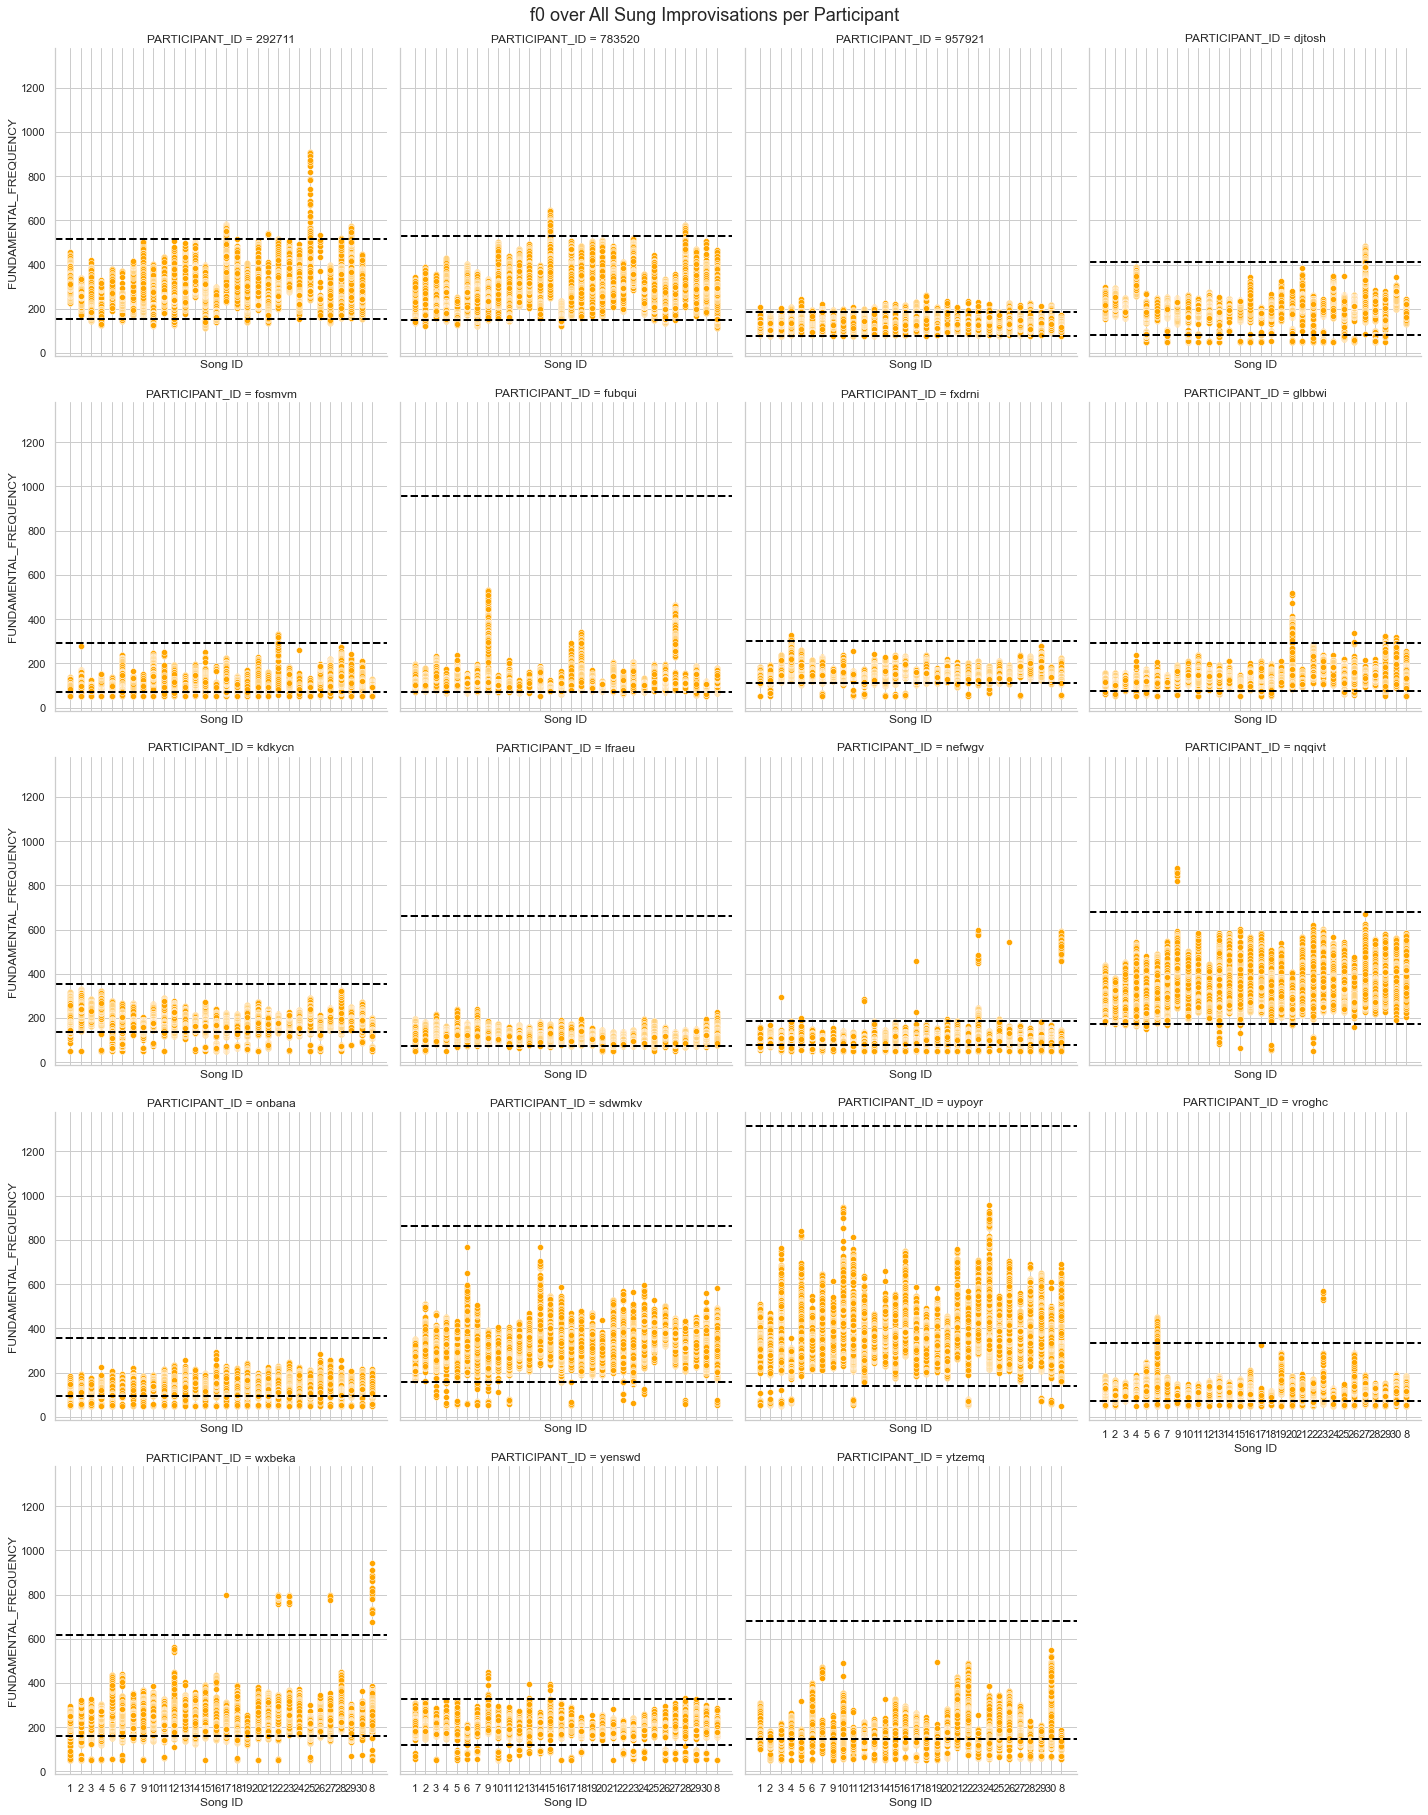

In [23]:
# f0 over songs per participant
_ = sns.relplot(data = df, x = df['SONG_ID'], y = df['FUNDAMENTAL_FREQUENCY'],
                col=df['PARTICIPANT_ID'], col_wrap=4, color='orange')

# Set title
_.fig.suptitle('f0 over All Sung Improvisations per Participant', y=1, va='baseline', fontsize=18)

# Add MAX & MIN MIDI note from VR data as horizontal lines on each subplot (per participant)
for i, ax in enumerate(_.axes.flat):
    ax.axhline(y=VR.loc[i,'MAX_f0'], linestyle='--', linewidth=2, color='black')
    ax.axhline(y=VR.loc[i,'MIN_f0'], linestyle='--', linewidth=2, color='black')
    ax.set_xlabel('Song ID', visible=True)

# Save
#plt.savefig(f"f0-over-songs_{condition}.png", dpi=300)

In [ ]:
# MIDI over songs per participant
_ = sns.relplot(data = df, x = df['SONG_ID'], y = df['MIDI_NOTE'],
                col=df['PARTICIPANT_ID'], col_wrap=4, color='orange')

# Set title
_.fig.suptitle('MIDI over Sung Improvisations per Participant', y=1, va='baseline', fontsize=18)

# Add MAX & MIN MIDI note from VR data as horizontal lines on each subplot (per participant)
for i, ax in enumerate(_.axes.flat):
    ax.axhline(y=VR.loc[i,'MAX_MIDI'], linestyle='--', linewidth=2, color='black')
    ax.axhline(y=VR.loc[i,'MIN_MIDI'], linestyle='--', linewidth=2, color='black')
    ax.set_xlabel('Song ID', visible=True)

# Save
plt.savefig(f"MIDI-over-songs_{condition}.png", dpi=300)

In [ ]:
# NG over songs per participant
_ = sns.relplot(data = df, x = df['SONG_ID'], y = df['NG'],
                col=df['PARTICIPANT_ID'], col_wrap=4, color='orange')
# Set title
_.fig.suptitle('NG over Time for All Sung Improvisations per Participant', y=1, va='baseline', fontsize=18)

# Add MAX & MIN MIDI note from VR data as horizontal lines on each subplot (per participant)
for i, ax in enumerate(_.axes.flat):
    ax.axhline(y=VR.loc[i,'MAX_MIDI'], linestyle='--', linewidth=2, color='black')
    ax.axhline(y=VR.loc[i,'MIN_MIDI'], linestyle='--', linewidth=2, color='black')
    ax.set_xlabel('Song ID', visible=True)

# Save
#plt.savefig(f"NG-over-time_{condition}.png", dpi=300)

## Save Clean Data.

In [ ]:
# Save the df # IMPROV or SF
# df.to_csv("spectral_data_Cs.csv")